# MobileNetV2 -- Lentil Disease Classification (Teacher Training)

This notebook trains a **MobileNetV2** model for lentil disease classification as part of **Phase 1: Teacher Training on the Lentil Dataset** in a cross-crop knowledge distillation pipeline.

**Task:** 4-class classification -- Ascochyta Blight, Lentil Rust, Normal, Powdery Mildew  
**Dataset:** Lentil Augmented Dataset (4540 train / 456 val / 457 test images)

## Imports and Setup

Importing required libraries and dependencies.

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os
from tensorflow.keras.layers import Flatten, Dense

## Data Loading and Preprocessing

Loading the dataset and applying preprocessing (normalization, augmentation, etc.).

In [2]:
train_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Train'
val_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Validation'
img_size = 224
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 4540 files belonging to 4 classes.
Found 456 files belonging to 4 classes.


## Model Architecture -- Experiment 1 (Functional API, Frozen Base)

The pretrained **MobileNetV2** backbone (ImageNet weights) is loaded *without* the top classification layer. All base layers are **frozen**, and a custom head is added:

`GlobalAveragePooling2D -> Dense(1024, relu) -> Dense(4, softmax)`

In [3]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

for layer in base_model.layers:
    layer.trainable = False 

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(1024, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Code

In [4]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 3,573,828 (13.63 MB)

 Trainable params: 1,315,844 (5.02 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Training Configuration -- Experiment 1

| Parameter | Value |
|---|---|
| Optimizer | Adam (default lr) |
| Loss | SparseCategoricalCrossentropy |
| Epochs | 20 (EarlyStopping patience=5) |
| Batch Size | 32 |
| Checkpoint | Best val_accuracy |

In [5]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

## Training

Compiling and training the model with appropriate callbacks (EarlyStopping, ModelCheckpoint) to prevent overfitting and save the best model.

In [6]:
model.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False), 
    metrics=['accuracy']
)
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    shuffle = False
)

Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.4227 - loss: 1.6032
Epoch 1: val_accuracy improved from -inf to 0.60307, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 61s 400ms/step - accuracy: 0.4233 - loss: 1.6006 - val_accuracy: 0.6031 - val_loss: 0.9912
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5791 - loss: 1.0231
Epoch 2: val_accuracy improved from 0.60307 to 0.61842, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 63s 443ms/step - accuracy: 0.5792 - loss: 1.0229 - val_accuracy: 0.6184 - val_loss: 0.9805
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.6365 - loss: 0.9127
Epoch 3: val_accuracy did not improve from 0.61842
142/142 ━━━━━━━━━━━━━━━━━━━━ 62s 438ms/step - accuracy: 0.6366 - loss: 0.9125 - val_accuracy: 0.5614 - val_loss: 0.9750
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6644 - loss: 0.8655
Epoch 4: val_accuracy improved from 0.61842 to 0.63158, saving

### Training Results -- Experiment 1

Loss and accuracy curves for Experiment 1 (frozen base, Functional API).

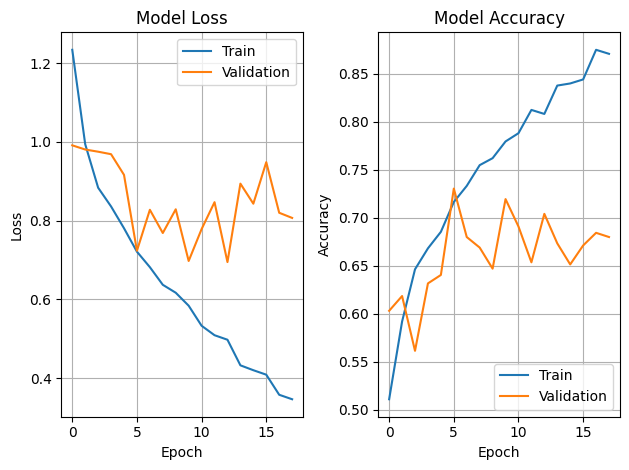

In [7]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import random
from PIL import Image
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])  
plt.plot(history.history['val_accuracy']) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

plt.tight_layout()
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\loss_accuracy_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
plt.show()

## Data Loading and Preprocessing

Loading the dataset and applying preprocessing (normalization, augmentation, etc.).

In [8]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Test",
    seed= 123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle = False
)

Found 457 files belonging to 4 classes.


## Model Evaluation

Evaluating the model performance on train, validation, and test datasets.

In [9]:
model.evaluate(test_ds)

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 324ms/step - accuracy: 0.7120 - loss: 0.6920


[0.700279712677002, 0.6980306506156921]

In [10]:
ts_length = len(test_ds)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_ds, steps= test_steps, verbose= 1)
valid_score = model.evaluate(val_ds, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_ds)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8438 - loss: 0.4176
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.6875 - loss: 0.7154
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 322ms/step - accuracy: 0.7120 - loss: 0.6920
Train Loss:  0.4176056385040283
Train Accuracy:  0.84375
--------------------
Validation Loss:  0.7153520584106445
Validation Accuracy:  0.6875
--------------------
Test Loss:  0.700279712677002
Test Accuracy:  0.6980306506156921


### Evaluation Metrics -- Experiment 1

Train / Validation / Test scores for Experiment 1.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names):
    """
    Plots the confusion matrix and prints the classification report.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        class_names (list): List of class names.
    """
    cm = confusion_matrix(y_true, y_pred)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))


    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (in %)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Confusion Matrix.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight') 
    plt.show()

## Code

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 374ms/step

Classification Report:

                  precision    recall  f1-score   support

Ascochyta blight       0.63      0.69      0.66       111
     Lentil Rust       0.74      0.95      0.83        95
          Normal       0.81      0.47      0.59       143
  Powdery Mildew       0.65      0.79      0.71       108

        accuracy                           0.70       457
       macro avg       0.71      0.72      0.70       457
    weighted avg       0.71      0.70      0.69       457



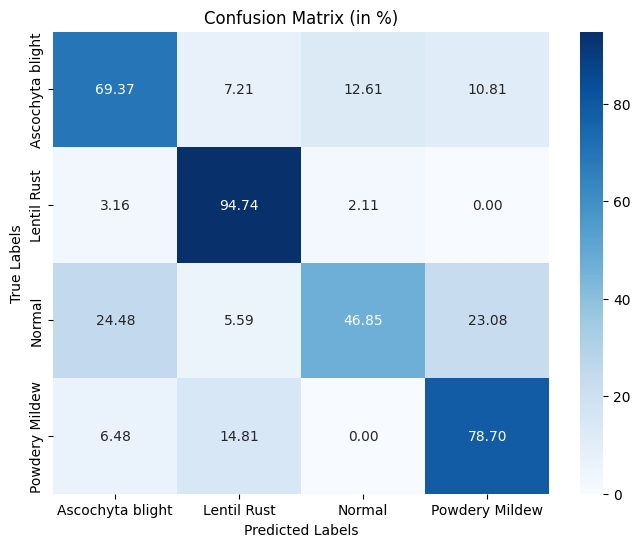

In [12]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

class_names =  ['Ascochyta blight', 'Lentil Rust', 'Normal', 'Powdery Mildew']

evaluate_model(y_true, y_pred, class_names)

### ROC Curves -- Experiment 1

Confusion matrix and classification report followed by multiclass ROC curves for Experiment 1.

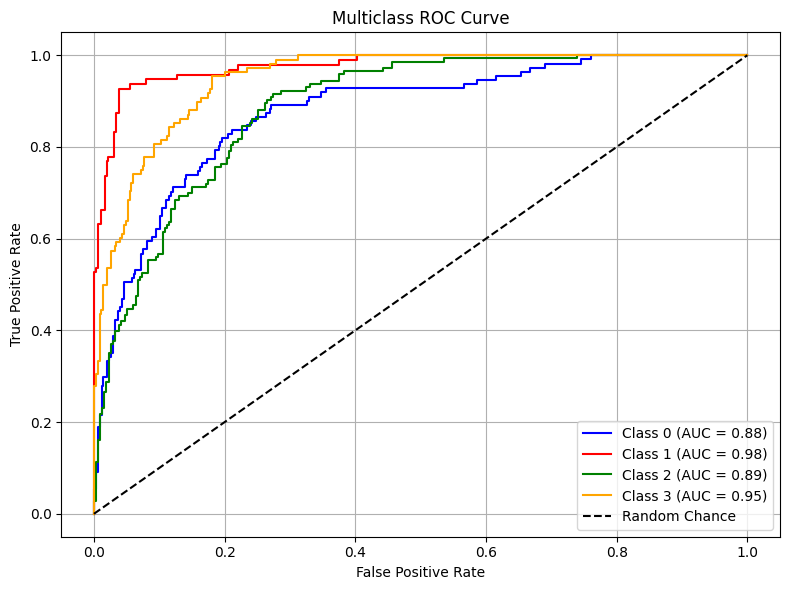

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = y_pred_probs.shape[1]

y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\ROC_Curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

---

## Experiment 2 -- Sequential API, Full Fine-Tuning

In this experiment the **MobileNetV2** backbone is loaded again, but this time **all layers are set to trainable** (`trainable = True`). A `Sequential` model is built:

`MobileNetV2 (all trainable) -> GlobalAveragePooling2D -> Dense(4096, relu) -> Dropout(0.2) -> Dense(4, softmax)`

| Parameter | Value |
|---|---|
| Optimizer | Adam (lr=1e-4) |
| Loss | CategoricalCrossentropy |
| Epochs | 20 (EarlyStopping patience=5) |
| Labels | One-hot (`label_mode='categorical'`) |

In [14]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras import layers, models, applications, optimizers

## Data Loading and Preprocessing

Loading the dataset and applying preprocessing (normalization, augmentation, etc.).

In [15]:
train_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Train'
val_dir = r'C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Validation'
img_size = 224
batch_size = 32
seed = 123
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True,
    label_mode='categorical' 
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    seed=seed,
    image_size=(img_size,img_size),
    batch_size=batch_size,
    shuffle=True,
    label_mode='categorical'
)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 4540 files belonging to 4 classes.
Found 456 files belonging to 4 classes.


## Imports and Setup

Importing required libraries and dependencies.

In [16]:
from keras import backend as K
from keras.preprocessing import image
from keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Activation, Dropout, Flatten, Dense
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D

## Model Architecture

Building the MobileNet model with transfer learning. Using ImageNet pre-trained weights with custom classification head for the disease classes.

In [17]:
resnet = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape= (img_size,img_size,3))

for layer in resnet.layers:
    layer.trainable = False

resnet.trainable = True
def build_model():
    model = Sequential()
    model.add(resnet)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(4, activation='softmax'))
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizers.Adam(1e-4),
        metrics=['accuracy'])
     
    return model

model = build_model()

## Code

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4096)                │       5,246,976 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │          16,388 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,521,348 (28.69 MB)

 Trainable params: 5,263,364 (20.08 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Imports and Setup

Importing required libraries and dependencies.

In [19]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

## Training

Compiling and training the model with appropriate callbacks (EarlyStopping, ModelCheckpoint) to prevent overfitting and save the best model.

In [20]:
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping,checkpoint],
    shuffle = False
)  

Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.4592 - loss: 1.2245
Epoch 1: val_accuracy improved from -inf to 0.60746, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 63s 419ms/step - accuracy: 0.4597 - loss: 1.2238 - val_accuracy: 0.6075 - val_loss: 1.0031
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.5665 - loss: 1.0187
Epoch 2: val_accuracy improved from 0.60746 to 0.62061, saving model to best_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 58s 408ms/step - accuracy: 0.5666 - loss: 1.0184 - val_accuracy: 0.6206 - val_loss: 0.9867
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.6292 - loss: 0.9236
Epoch 3: val_accuracy did not improve from 0.62061
142/142 ━━━━━━━━━━━━━━━━━━━━ 60s 422ms/step - accuracy: 0.6293 - loss: 0.9234 - val_accuracy: 0.6162 - val_loss: 0.9509
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.6516 - loss: 0.8805
Epoch 4: val_accuracy did not improve from 0.62061
142/142 ━━━

### Training Results -- Experiment 2

Loss and accuracy curves for Experiment 2 (full fine-tuning, Sequential API).

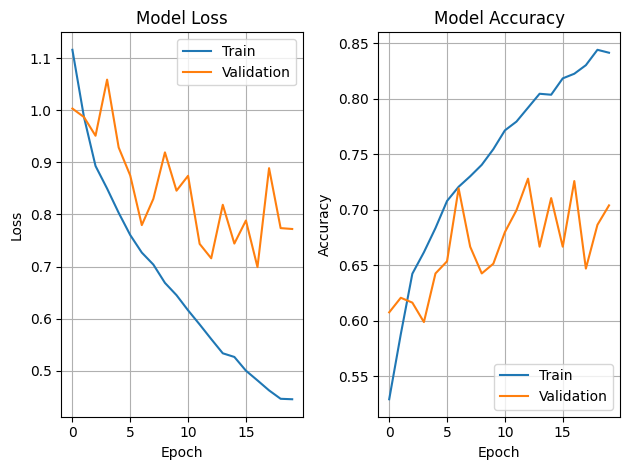

In [21]:
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])  
plt.plot(history.history['val_accuracy']) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

plt.tight_layout()
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\loss_accuracy_curve_1.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
plt.show()

## Data Loading and Preprocessing

Loading the dataset and applying preprocessing (normalization, augmentation, etc.).

In [22]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Lentil Augmented Dataset\Test",
    seed= 123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle = False,
    label_mode='categorical'
)

Found 457 files belonging to 4 classes.


## Model Evaluation

Evaluating the model performance on train, validation, and test datasets.

In [23]:
model.evaluate(test_ds)

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 622ms/step - accuracy: 0.6769 - loss: 0.7549


[0.6926642060279846, 0.7045952081680298]

In [24]:
ts_length = len(test_ds)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_ds, steps= test_steps, verbose= 1)
valid_score = model.evaluate(val_ds, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_ds)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step - accuracy: 0.9375 - loss: 0.3396
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step - accuracy: 0.6250 - loss: 0.9074
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 644ms/step - accuracy: 0.6769 - loss: 0.7549
Train Loss:  0.33956196904182434
Train Accuracy:  0.9375
--------------------
Validation Loss:  0.9073888659477234
Validation Accuracy:  0.625
--------------------
Test Loss:  0.6926642060279846
Test Accuracy:  0.7045952081680298


### Evaluation Metrics -- Experiment 2

Train / Validation / Test scores for Experiment 2.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names):
    """
    Plots the confusion matrix and prints the classification report.

    Args:
        y_true (array-like): True labels (1D array of class indices).
        y_pred (array-like): Predicted labels (1D array of class indices).
        class_names (list): List of class names.
    """
    cm = confusion_matrix(y_true, y_pred)

    print("\nClassification Report:\n")   
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (in %)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\Confusion Matrix_1.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight') 
    plt.show()

## Code

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Classification Report:

                  precision    recall  f1-score   support

Ascochyta blight       0.71      0.61      0.66       111
     Lentil Rust       0.68      0.94      0.79        95
          Normal       0.72      0.51      0.60       143
  Powdery Mildew       0.71      0.85      0.77       108

        accuracy                           0.70       457
       macro avg       0.71      0.73      0.7

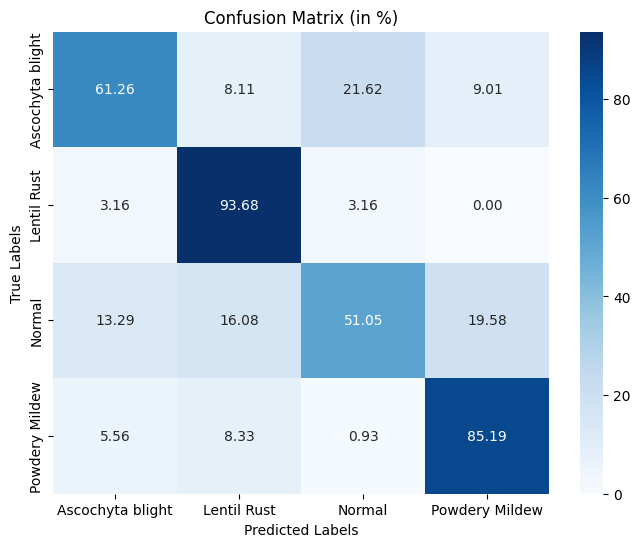

In [26]:
y_true = []
y_pred_proba = []

for images, labels in test_ds:
    y_true.append(labels.numpy())
    preds = model.predict(images)
    y_pred_proba.append(preds)

y_true = np.vstack(y_true)
y_pred_proba = np.vstack(y_pred_proba)

if y_true.shape[1] > 1:
    y_true = np.argmax(y_true, axis=1)
else:
    y_true = y_true.flatten()

y_pred = np.argmax(y_pred_proba, axis=1)

class_names = ['Ascochyta blight', 'Lentil Rust', 'Normal', 'Powdery Mildew']

evaluate_model(y_true, y_pred, class_names)

### ROC Curves -- Experiment 2

Confusion matrix, classification report, and multiclass ROC curves for Experiment 2.

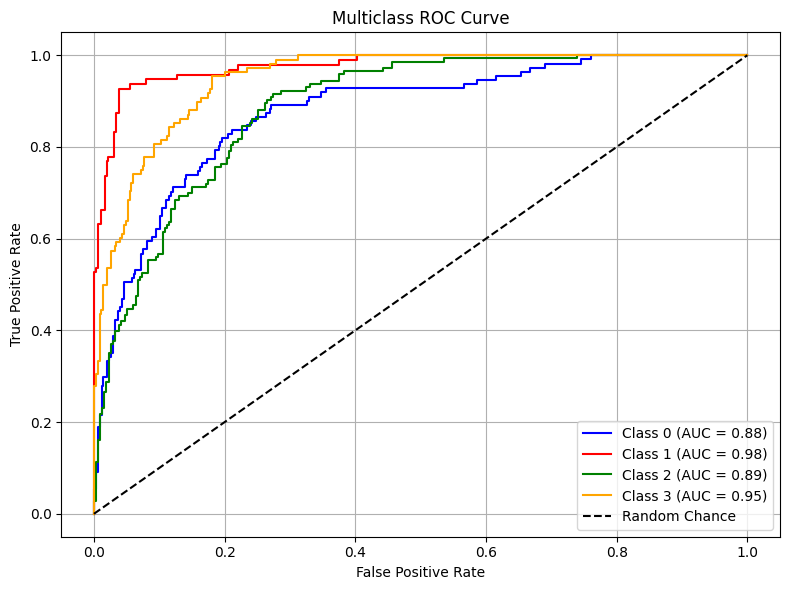

In [27]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = y_pred_probs.shape[1]

y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
save_path = r"C:\Users\k nithin\OneDrive\Desktop\M.Tech Project\ROC_Curve_1.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## Code